<a href="https://colab.research.google.com/github/XuanTruong28/Climate-impact-mekong-delta-agriculture/blob/main/SEMINAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analyzing the Impact of Meteorological Anomalies on Agricultural Prices in the Mekong Delta (1/2021-8/2025).


# I.Preprocessing

Import Library

In [7]:
import pandas as pd
import requests
import time
import numpy as np
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

Collect weather data

In [8]:
# Cụm
clusters = {
    'Man': {'Ben_Tre': (10.2, 106.4), 'Tra_Vinh': (9.9, 106.3), 'Soc_Trang': (9.6, 106.0), 'Bac_Lieu': (9.3, 105.7), 'Ca_Mau': (9.2, 104.9), 'Kien_Giang': (10.0, 105.1)},
    'Lut': {'An_Giang': (10.5, 105.1), 'Dong_Thap': (10.4, 105.6), 'Long_An': (10.7, 106.0)},
    'Ngot': {'Can_Tho': (10.0, 105.7), 'Vinh_Long': (10.2, 105.9), 'Tien_Giang': (10.4, 106.3), 'Hau_Giang': (9.8, 105.5)}
}

params = "T2M,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN"
start_date = "20210101"
end_date = "20250831"

all_clusters_daily = []


for cluster_key, provinces in clusters.items():
    cluster_prov_data = []
    print(f"\nLoad data {cluster_key}...")

    for prov_name, (lat, lon) in provinces.items():
        url = (f"https://power.larc.nasa.gov/api/temporal/daily/point?"
               f"parameters={params}&community=AG&longitude={lon}&latitude={lat}&"
               f"start={start_date}&end={end_date}&format=JSON")

        try:
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                records = response.json()['properties']['parameter']
                df = pd.DataFrame({
                    'Date': pd.to_datetime(list(records['T2M'].keys()), format='%Y%m%d'),
                    'Temp': list(records['T2M'].values()),
                    'Rain': list(records['PRECTOTCORR'].values()),
                    'Humid': list(records['RH2M'].values()),
                    'Solar': list(records['ALLSKY_SFC_SW_DWN'].values())
                })
                cluster_prov_data.append(df)
                print(f"  + {prov_name}: Xong")
                time.sleep(0.5)
        except Exception as e:
            print(f"{prov_name}: {e}")

    if cluster_prov_data:
        # Aver Cluster
        df_cluster_daily = pd.concat(cluster_prov_data).groupby('Date').mean().reset_index()

        # --- Salnity & Water level (Logic Hydro) ---
        def add_hydro(row):
            month = row['Date'].month
            if month in [2, 3, 4, 5]:
                sal = np.random.uniform(3.0, 12.0) + (row['Temp'] * 0.05) - (row['Rain'] * 0.3)
            else:
                sal = np.random.uniform(0.1, 1.0)

            if month in [9, 10, 11]:
                wl = np.random.uniform(2.0, 3.5) + (row['Rain'] * 0.04)
            else:
                wl = np.random.uniform(0.5, 1.5)
            return pd.Series([max(0.1, sal), max(0.1, wl)])

        df_cluster_daily[['Salinity', 'WaterLevel']] = df_cluster_daily.apply(add_hydro, axis=1)
        df_cluster_daily.columns = ['Date'] + [f"{col}_{cluster_key}" for col in df_cluster_daily.columns if col != 'Date']
        all_clusters_daily.append(df_cluster_daily)

# Merge Master
df_final = all_clusters_daily[0]
for next_df in all_clusters_daily[1:]:
    df_final = pd.merge(df_final, next_df, on='Date', how='inner')

# NA
df_final = df_final.replace(-999, pd.NA).fillna(method='ffill')

print("\n--- HOÀN TẤT DỮ LIỆU ---")
print(f"Số dòng: {len(df_final)}")
print("Danh sách cột mới:", df_final.columns.tolist())
df_final.to_csv('NASA_Mekong_Data_2021_2025.csv', index=False)
print("Đã lưu file: NASA_Mekong_Data_2021_2025.csv")


Load data Man...
  + Ben_Tre: Xong
  + Tra_Vinh: Xong
  + Soc_Trang: Xong
  + Bac_Lieu: Xong
  + Ca_Mau: Xong


KeyboardInterrupt: 

Collect rice & durian price

In [9]:
from google.colab import drive
drive.mount('/content/drive')

path_rice = '/content/drive/MyDrive/seminar/rice.csv'
path_durian = '/content/drive/MyDrive/seminar/durian.csv'

df_rice = pd.read_csv(path_rice)
df_durian = pd.read_csv(path_durian)

def categorize_items(df, item_col, crop_type):
    if crop_type == 'rice':
        # Nhóm lúa
        conditions = [
            df[item_col].str.contains('ST|Đài|Thơm|RVT|CLC', case=False, na=False),
            df[item_col].str.contains('thường|IR|504|6976|tấm', case=False, na=False)
        ]
        choices = ['Rice_Premium', 'Rice_Common']
        df['category'] = np.select(conditions, choices, default='Rice_Other')
    else:
        # Nhóm sầu riêng
        conditions = [
            df[item_col].str.contains('Ri 6|Ri6', case=False, na=False),
            df[item_col].str.contains('cơm vàng|hạt lép|KQX', case=False, na=False)
        ]
        choices = ['Durian_Ri6', 'Durian_Other']
        df['category'] = np.select(conditions, choices, default='Durian_Common')
    return df

df_rice = categorize_items(df_rice, 'item_name', 'rice')
df_durian = categorize_items(df_durian, 'item_name', 'durian')

#Clustering
market_map = {
    'An Giang': 'Lut', 'Đồng Tháp': 'Lut', 'Long An': 'Lut',
    'Tiền Giang': 'Man', 'Bến Tre': 'Man', 'Trà Vinh': 'Man', 'Sóc Trăng': 'Man', 'Bạc Liêu': 'Man', 'Cà Mau': 'Man',
    'Cần Thơ': 'Ngot', 'Vĩnh Long': 'Ngot', 'Hậu Giang': 'Ngot', 'Kiên Giang': 'Ngot'
}
df_rice['cluster'] = df_rice['market'].map(market_map)
df_durian['cluster'] = df_durian['market'].map(market_map)

# Aver
def process_to_monthly(df, price_col):
    df['Date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
    return df.groupby(['Date', 'cluster', 'category'])[price_col].mean().unstack(level=[1, 2])

rice_monthly = process_to_monthly(df_rice, 'price_rice')
durian_monthly = process_to_monthly(df_durian, 'price_durian')

# 5. Hợp nhất thành Dataset cuối cùng
final_df = pd.concat([rice_monthly, durian_monthly], axis=1).ffill().bfill()
final_df.columns = [f"{col[1]}_{col[0]}" for col in final_df.columns]
final_df.to_csv('Agri_Price_Input.csv')
print("Đã tạo file Input thành công!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã tạo file Input thành công!


Gộp data tổng

In [10]:

df_agri = pd.read_csv('Agri_Price_Input.csv')
df_weather = pd.read_csv('NASA_Mekong_Data_2021_2025.csv')


df_agri['Date'] = pd.to_datetime(df_agri['Date'])
df_weather['Date'] = pd.to_datetime(df_weather['Date'])


cols_to_keep = [c for c in df_weather.columns if 'Rice' not in c and 'Durian' not in c]
df_weather_clean = df_weather[cols_to_keep]

df_master = pd.merge(df_weather_clean, df_agri, on='Date', how='left')

price_cols = [c for c in df_agri.columns if c != 'Date']

df_master = df_master.sort_values('Date')
df_master[price_cols] = df_master[price_cols].ffill()

df_master[price_cols] = df_master[price_cols].bfill()

print("--- KIỂM TRA DỮ LIỆU ---")
print(f"Tổng số dòng: {len(df_master)}")
print(f"Số dòng bị trống giá Rice_Common_Man: {df_master['Rice_Common_Man'].isnull().sum()}")

df_master.to_csv('Mekong_Master_Daily.csv', index=False)



--- KIỂM TRA DỮ LIỆU ---
Tổng số dòng: 1704
Số dòng bị trống giá Rice_Common_Man: 0


Clean data

In [11]:
df = pd.read_csv('Mekong_Master_Daily.csv')

print("Số lượng giá trị trống mỗi cột:")
print(df.isnull().sum())

print("\nKiểm tra giá trị nhỏ nhất của các cột số:")
print(df.describe().loc['min'])

Số lượng giá trị trống mỗi cột:
Date                 0
Temp_Man             0
Rain_Man             0
Humid_Man            0
Solar_Man            0
Salinity_Man         0
WaterLevel_Man       0
Temp_Lut             0
Rain_Lut             0
Humid_Lut            0
Solar_Lut            0
Salinity_Lut         0
WaterLevel_Lut       0
Temp_Ngot            0
Rain_Ngot            0
Humid_Ngot           0
Solar_Ngot           0
Salinity_Ngot        0
WaterLevel_Ngot      0
Rice_Common_Ngot     0
Rice_Other_Ngot      0
Rice_Other_Man       0
Rice_Common_Lut      0
Rice_Other_Lut       0
Rice_Premium_Lut     0
Rice_Common_Man      0
Rice_Premium_Man     0
Rice_Premium_Ngot    0
Durian_Ri6_Man       0
Durian_Other_Lut     0
Durian_Common_Man    0
Durian_Other_Man     0
Durian_Other_Ngot    0
Durian_Ri6_Lut       0
dtype: int64

Kiểm tra giá trị nhỏ nhất của các cột số:
Temp_Man                23.001667
Rain_Man                 0.000000
Humid_Man               54.256667
Solar_Man                3.9

Outliers

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

def handle_outliers_v2(df, columns):
    df_cleaned = df.copy()

    for col in columns:
        # IQR
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1

        #Border
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        #logic
        if 'Rain' in col:
            upper_rain = Q3 + 3.0 * IQR
            df_cleaned[col] = df_cleaned[col].clip(lower=0, upper=upper_rain)

        elif 'Humid' in col:
            df_cleaned[col] = df_cleaned[col].clip(lower=max(0, lower_bound), upper=100)

        elif 'Salinity' in col:
            df_cleaned[col] = df_cleaned[col].clip(lower=0, upper=35)

        elif 'Price' in col:
            df_cleaned[col] = df_cleaned[col].clip(lower=max(0, lower_bound), upper=upper_bound)

        elif 'Temp' in col:
            df_cleaned[col] = df_cleaned[col].clip(lower=max(15, lower_bound), upper=min(45, upper_bound))

        elif 'WaterLevel' in col:
            df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, upper=upper_bound)

        else:
            df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, upper=upper_bound)

    return df_cleaned

df_cleaned = handle_outliers_v2(df, numeric_cols)

df_cleaned[numeric_cols] = df_cleaned[numeric_cols].round(4)

print("--- ĐÃ XỬ LÝ OUTLIERS ---")
print(df_cleaned[numeric_cols].agg(['min', 'max']))

--- ĐÃ XỬ LÝ OUTLIERS ---
     Temp_Man  Rain_Man  Humid_Man  Solar_Man  Salinity_Man  WaterLevel_Man  \
min   24.6608    0.0000    58.6971     8.1271        0.1000          0.5009   
max   30.6275   31.4975    93.0000    25.8617       13.4294          2.4011   

     Temp_Lut  Rain_Lut  Humid_Lut  Solar_Lut  ...  Rice_Premium_Lut  \
min   23.8488      0.00    49.7925     9.6092  ...            5536.0   
max   31.3454     31.45    94.9900    26.1667  ...           20000.0   

     Rice_Common_Man  Rice_Premium_Man  Rice_Premium_Ngot  Durian_Ri6_Man  \
min        5901.2500         7301.1111          6329.7143         43515.5   
max        7003.6071         7301.1111         13351.0000        103875.0   

     Durian_Other_Lut  Durian_Common_Man  Durian_Other_Man  Durian_Other_Ngot  \
min           70000.0            75000.0           41667.0         40425.3333   
max           70000.0            75000.0           88750.0         66571.8750   

     Durian_Ri6_Lut  
min         49250.0  

Boxplot (Kiểm tra Outliers)

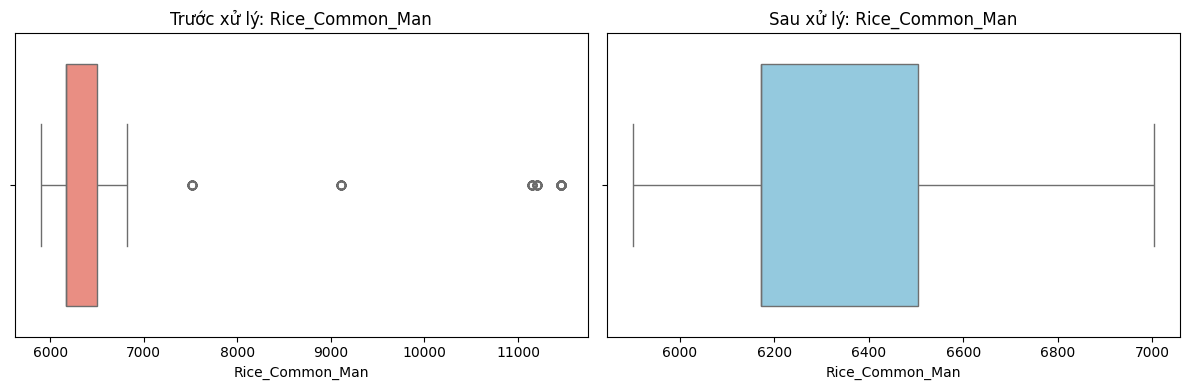

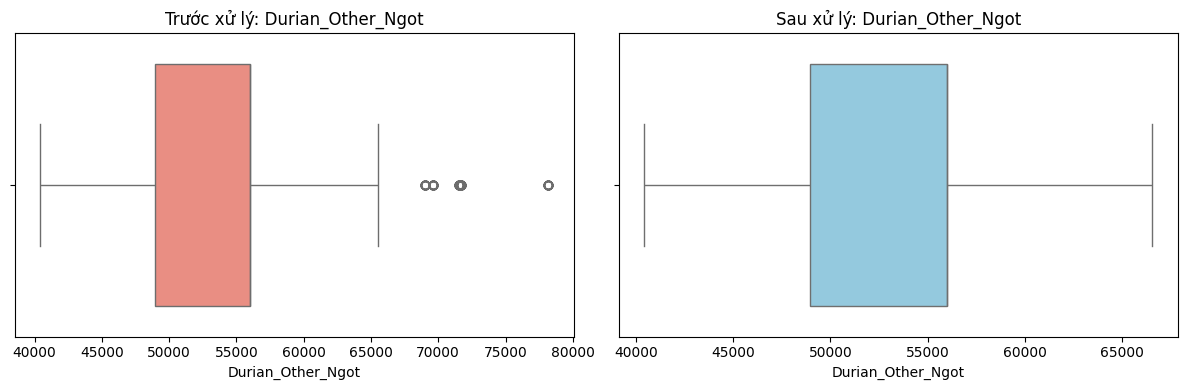

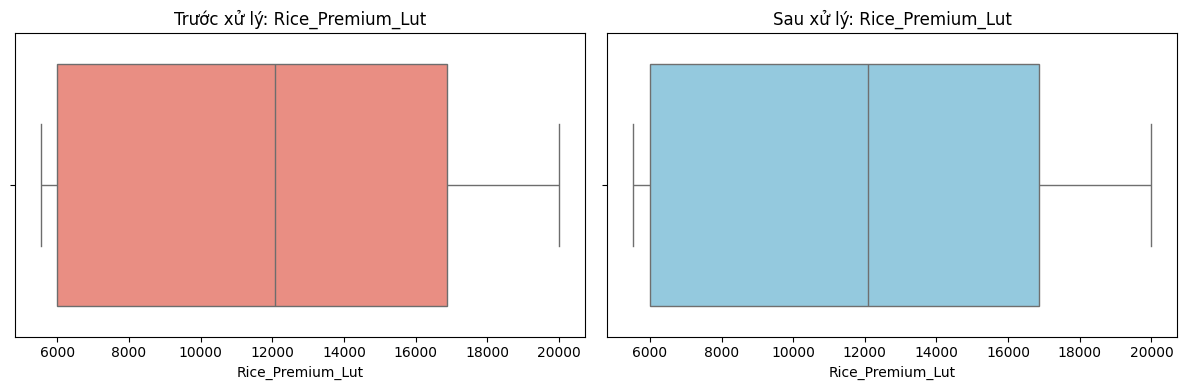

In [13]:
def plot_comparison(df_old, df_new, column_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.boxplot(x=df_old[column_name], color='salmon')
    plt.title(f'Trước xử lý: {column_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_new[column_name], color='skyblue')
    plt.title(f'Sau xử lý: {column_name}')

    plt.tight_layout()
    plt.show()

#Draw
plot_comparison(df, df_cleaned, 'Rice_Common_Man')
plot_comparison(df, df_cleaned, 'Durian_Other_Ngot')
plot_comparison(df, df_cleaned, 'Rice_Premium_Lut')

# II.Feature Engineering

Tạo các biến trễ (Lag) và biến mùa vụ.

In [14]:
df = pd.read_csv('Mekong_Master_Daily.csv')
df['Date'] = pd.to_datetime(df['Date'])

def perform_feature_engineering_v2(df):
    new_df = df.copy()

    new_df['Month'] = new_df['Date'].dt.month
    new_df['DayOfYear'] = new_df['Date'].dt.dayofyear
    new_df['Is_Rainy_Season'] = new_df['Month'].apply(lambda x: 1 if 5 <= x <= 11 else 0)

    #Lag
    climate_factors = ['Temp', 'Rain', 'Humid', 'Solar', 'Salinity', 'WaterLevel']
    suffixes = ['Man', 'Lut', 'Ngot']

    for s in suffixes:
        for feat in climate_factors:
            col = f'{feat}_{s}'
            if col in new_df.columns:
                new_df[f'{col}_Lag7'] = new_df[col].shift(7)

                new_df[f'{col}_Lag30'] = new_df[col].shift(30)

                new_df[f'{col}_Mean7'] = new_df[col].rolling(window=7).mean()

                new_df[f'{col}_Std7'] = new_df[col].rolling(window=7).std()

    # ffill bfill
    new_df = new_df.sort_values('Date')
    new_df = new_df.bfill().ffill()

    return new_df

df_featured = perform_feature_engineering_v2(df)

print(f"Dữ liệu gốc: {df.shape}")
print(f"Dữ liệu sau Engineering: {df_featured.shape}")
print("\nCác cột mới tạo tiêu biểu:")
print([c for c in df_featured.columns if 'Lag' in c or 'Mean' in c][:10])

df_featured.to_csv('Mekong_Final_Features_v2.csv', index=False, encoding='utf-8-sig')

Dữ liệu gốc: (1704, 34)
Dữ liệu sau Engineering: (1704, 109)

Các cột mới tạo tiêu biểu:
['Temp_Man_Lag7', 'Temp_Man_Lag30', 'Temp_Man_Mean7', 'Rain_Man_Lag7', 'Rain_Man_Lag30', 'Rain_Man_Mean7', 'Humid_Man_Lag7', 'Humid_Man_Lag30', 'Humid_Man_Mean7', 'Solar_Man_Lag7']


# III.EDA & Regional Splitting

Phân loại data Mặn Ngọt Lụt

In [15]:
df = pd.read_csv('Mekong_Final_Features_v2.csv')
df['Date'] = pd.to_datetime(df['Date'])

cluster_suffixes = ['Man', 'Lut', 'Ngot']

for suffix in cluster_suffixes:

    cluster_cols = [col for col in df.columns if f'_{suffix}' in col]

    valid_cols = ['Date'] + cluster_cols
    df_cluster = df[valid_cols].copy()

    filename = f'Data_Cluster_{suffix}.csv'
    df_cluster.to_csv(filename, index=False, encoding='utf-8-sig')

    print(f"--- Đã hoàn thành Cụm {suffix} ---")
    print(f"Số lượng biến: {len(cluster_cols)} (Bao gồm biến gốc và biến Feature Engineering)")
    print(f"File: {filename}")

--- Đã hoàn thành Cụm Man ---
Số lượng biến: 36 (Bao gồm biến gốc và biến Feature Engineering)
File: Data_Cluster_Man.csv
--- Đã hoàn thành Cụm Lut ---
Số lượng biến: 35 (Bao gồm biến gốc và biến Feature Engineering)
File: Data_Cluster_Lut.csv
--- Đã hoàn thành Cụm Ngot ---
Số lượng biến: 34 (Bao gồm biến gốc và biến Feature Engineering)
File: Data_Cluster_Ngot.csv


Biểu đồ so sánh sự biến động(Line chart)

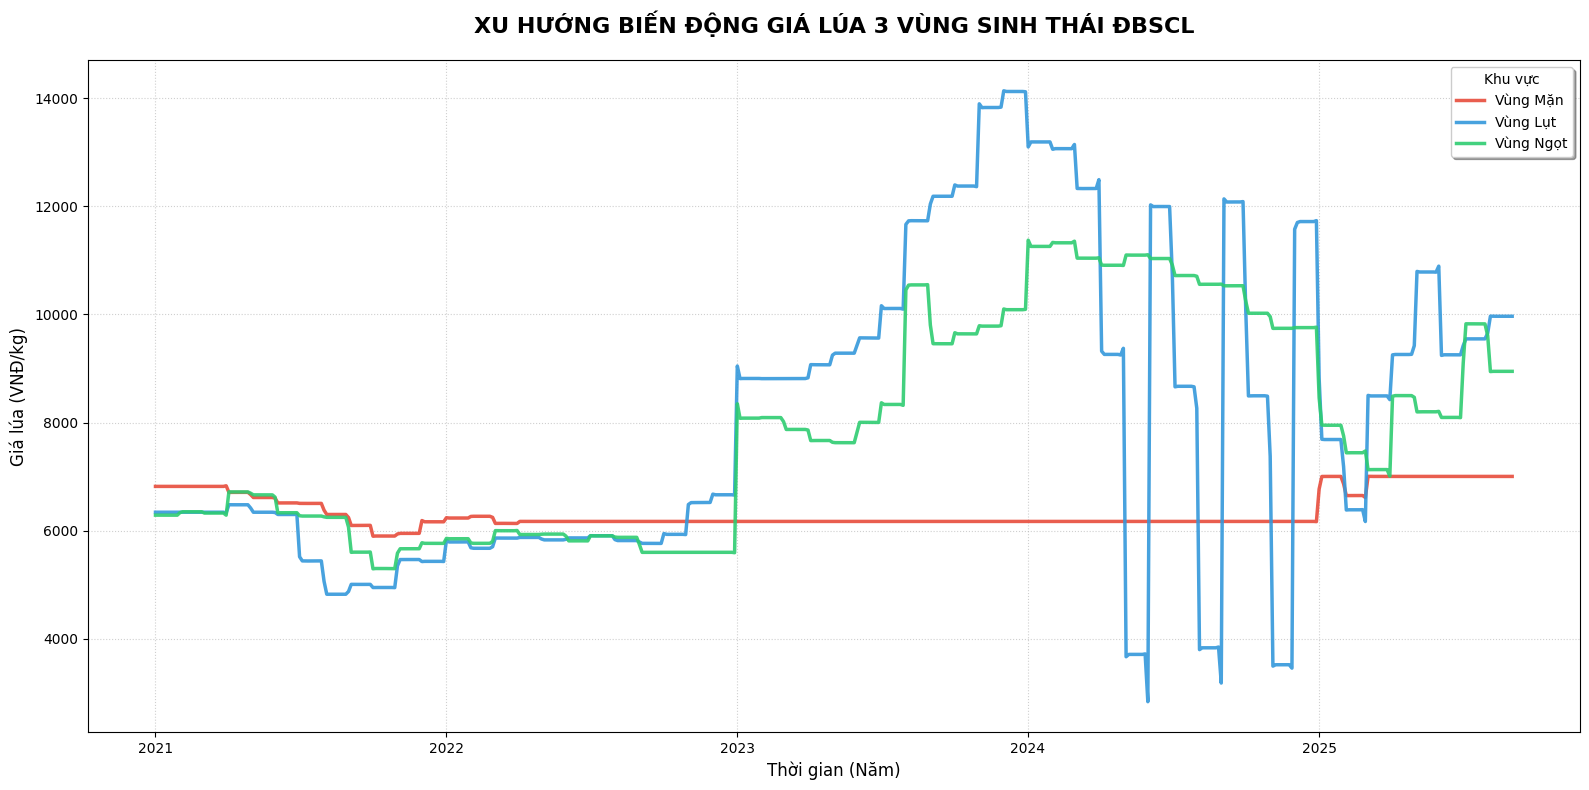

In [16]:
from scipy.interpolate import make_interp_spline
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('Mekong_Final_Features_v2.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_cleaned = handle_outliers_v2(df, numeric_cols)

x = np.arange(len(df_cleaned))
x_smooth = np.linspace(x.min(), x.max(), 500)
date_smooth = pd.to_datetime(np.interp(x_smooth, x, df_cleaned['Date'].values.astype(np.int64)))

groups = [
    ('Rice_Common_Man', 'Vùng Mặn', '#e74c3c'),
    ('Rice_Common_Lut', 'Vùng Lụt', '#3498db'),
    ('Rice_Common_Ngot', 'Vùng Ngọt', '#2ecc71')
]

plt.figure(figsize=(16, 8))

for col, label, color in groups:
    if col in df_cleaned.columns:
        y = df_cleaned[col].values
        spline = make_interp_spline(x, y, k=3)
        y_smooth = spline(x_smooth)

        plt.plot(date_smooth, y_smooth, label=label, color=color, linewidth=2.5, alpha=0.9)

plt.title('XU HƯỚNG BIẾN ĐỘNG GIÁ LÚA 3 VÙNG SINH THÁI ĐBSCL', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Giá lúa (VNĐ/kg)', fontsize=12)
plt.xlabel('Thời gian (Năm)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Khu vực', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

Biểu đồ Biến động (Time-series)

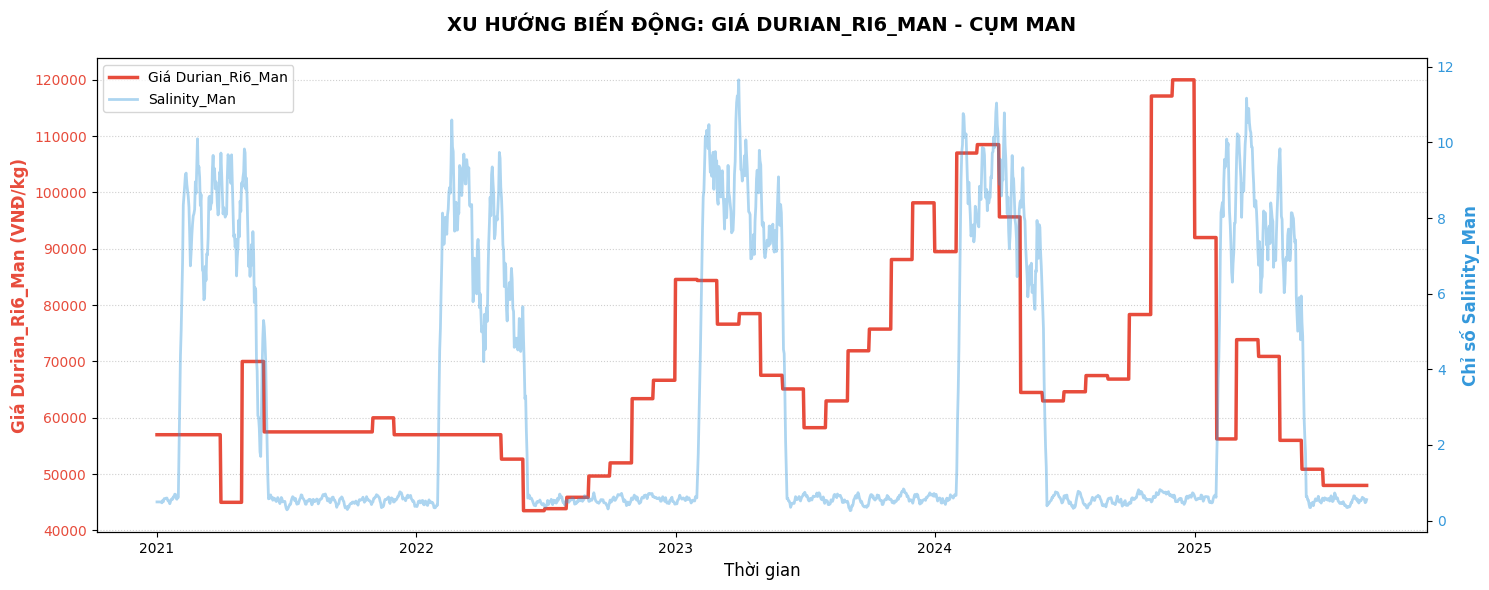

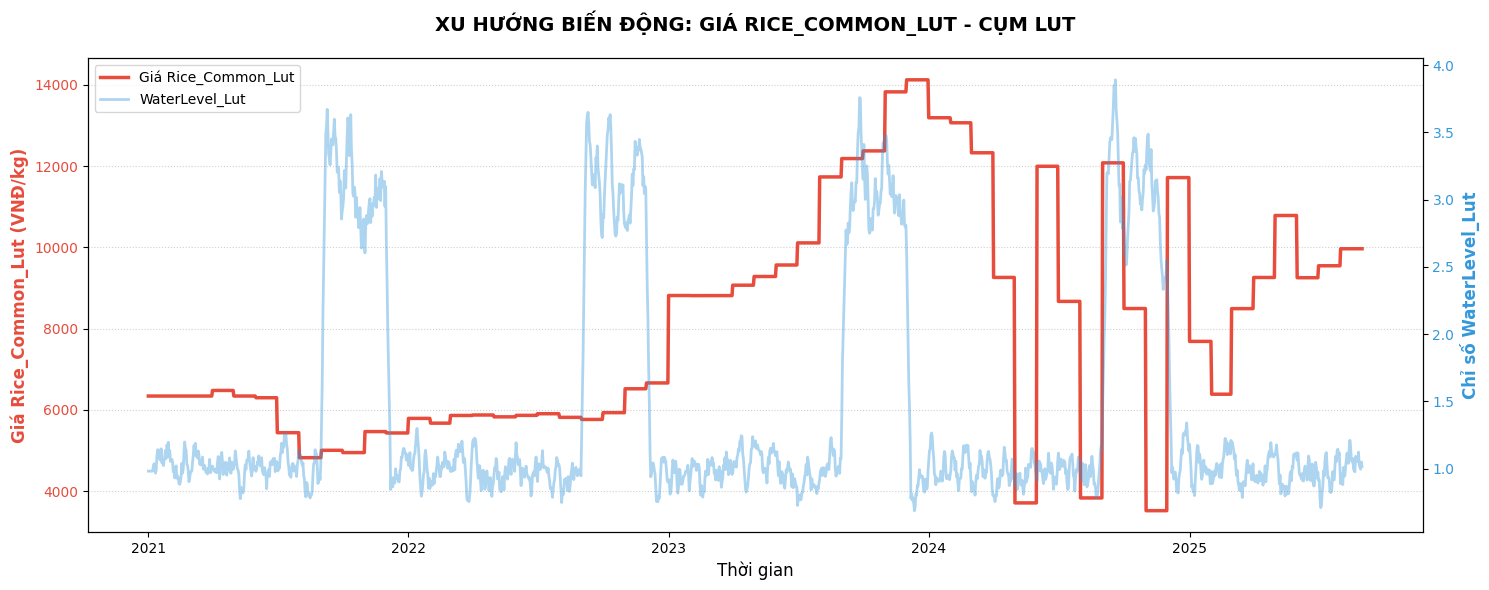

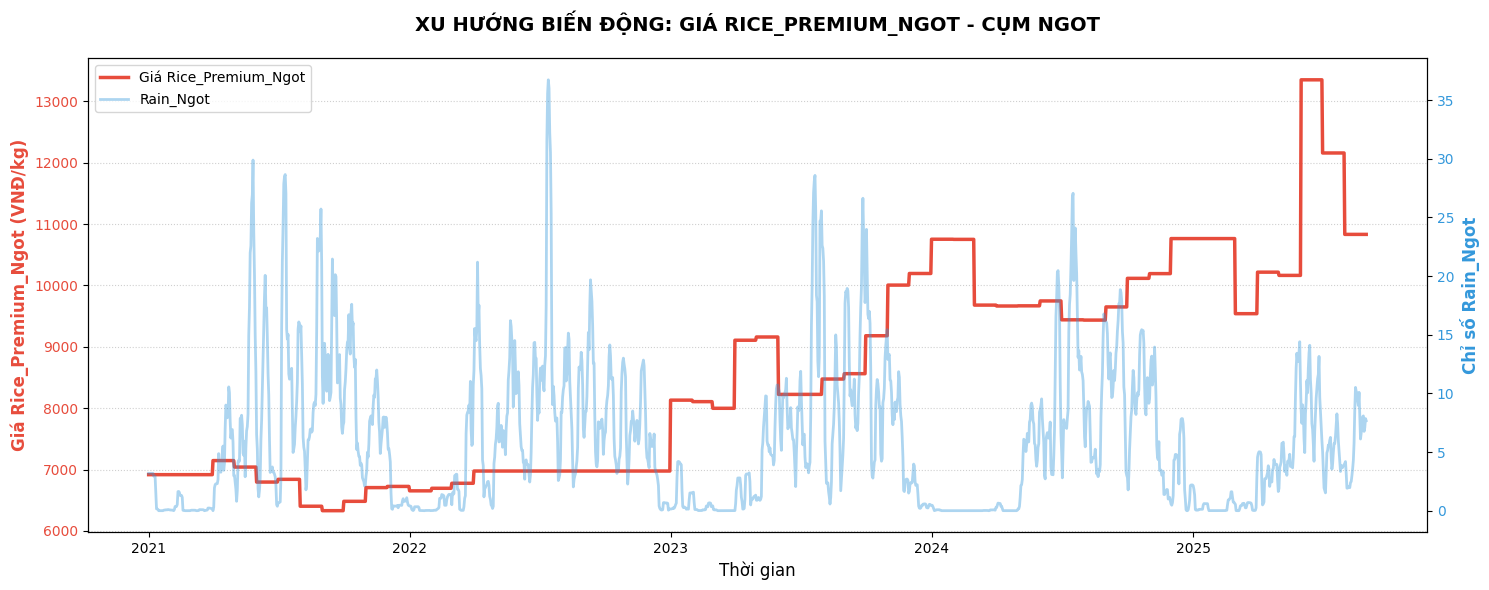

In [17]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('default')

df_f = pd.read_csv('Mekong_Final_Features_v2.csv')
df_f['Date'] = pd.to_datetime(df_f['Date'])

def plot_smooth_timeseries(df, cluster_name, price_base, climate_base):

    p_col = f'{price_base}_Mean7' if f'{price_base}_Mean7' in df.columns else price_base
    c_col = f'{climate_base}_Mean7' if f'{climate_base}_Mean7' in df.columns else climate_base

    fig, ax1 = plt.subplots(figsize=(15, 6), facecolor='white')
    ax1.set_facecolor('white')

    color_price = '#e74c3c'
    ax1.set_xlabel('Thời gian', fontsize=12)
    ax1.set_ylabel(f'Giá {price_base} (VNĐ/kg)', color=color_price, fontweight='bold', fontsize=12)
    ax1.plot(df['Date'], df[p_col], color=color_price, linewidth=2.5, label=f'Giá {price_base}', zorder=3)
    ax1.tick_params(axis='y', labelcolor=color_price)

    ax2 = ax1.twinx()
    color_climate = '#3498db'
    ax2.set_ylabel(f'Chỉ số {climate_base}', color=color_climate, fontweight='bold', fontsize=12)
    ax2.plot(df['Date'], df[c_col], color=color_climate, alpha=0.4, linewidth=2, label=f'{climate_base}', zorder=2)
    ax2.tick_params(axis='y', labelcolor=color_climate)

    plt.title(f'XU HƯỚNG BIẾN ĐỘNG: GIÁ {price_base.upper()} - CỤM {cluster_name.upper()}',
              fontsize=14, fontweight='bold', pad=20)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white')

    ax1.grid(True, axis='y', linestyle=':', alpha=0.6)

    fig.tight_layout()
    plt.show()

if 'Durian_Ri6_Man' in df_f.columns:
    plot_smooth_timeseries(df_f, 'Man', 'Durian_Ri6_Man', 'Salinity_Man')

if 'Rice_Common_Lut' in df_f.columns:
    plot_smooth_timeseries(df_f, 'Lut', 'Rice_Common_Lut', 'WaterLevel_Lut')

if 'Rice_Premium_Ngot' in df_f.columns:
    plot_smooth_timeseries(df_f, 'Ngot', 'Rice_Premium_Ngot', 'Rain_Ngot')

**Biểu đồ "Sự kiện cực đoan" (Time-series lồng ghép)**

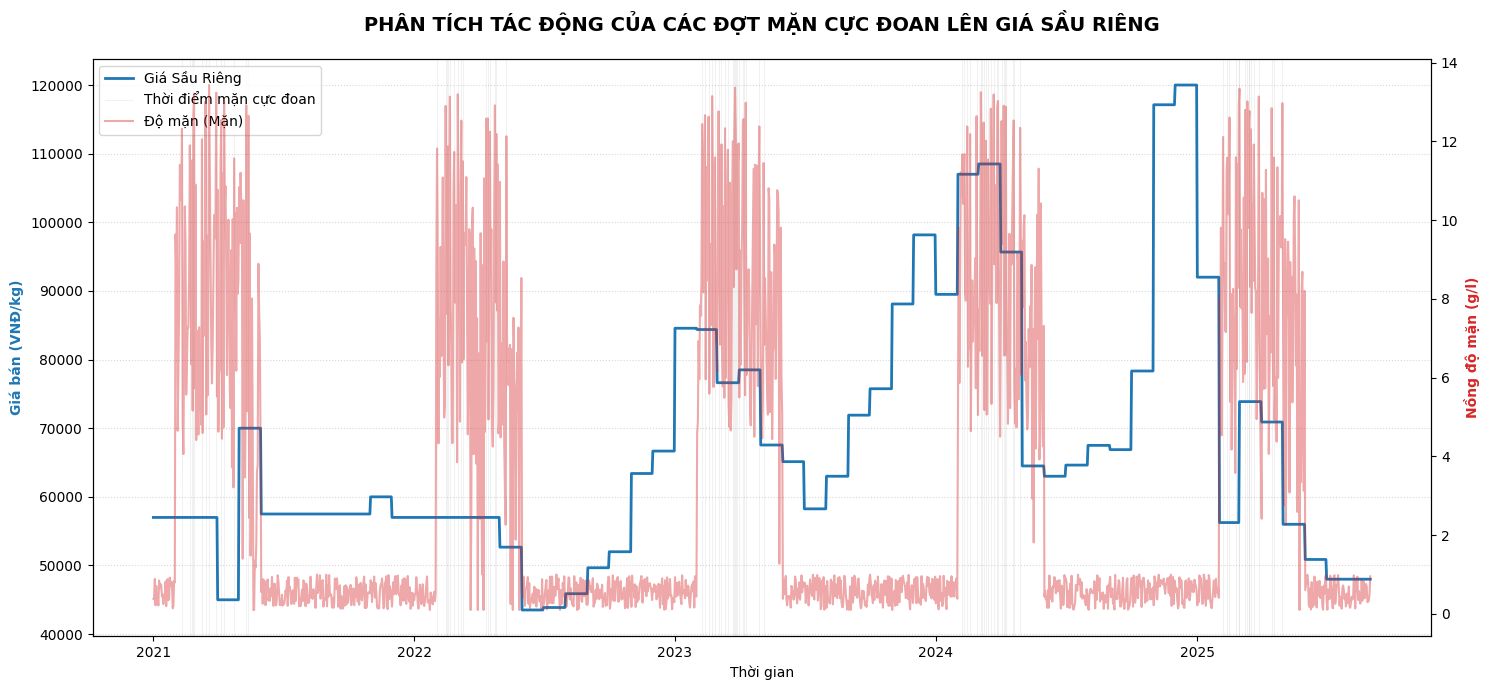

In [18]:

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('default')

plt.figure(figsize=(15, 7), facecolor='white')
ax1 = plt.gca()
ax1.set_facecolor('white')
ax2 = ax1.twinx()

ax1.plot(df_f['Date'], df_f['Durian_Ri6_Man'], color='#1f77b4',
         label='Giá Sầu Riêng', linewidth=2, zorder=3)
ax2.plot(df_f['Date'], df_f['Salinity_Man'], color='#d62728',
         alpha=0.4, label='Độ mặn (Mặn)', zorder=2)

threshold = df_f['Salinity_Man'].quantile(0.95)
extreme_events = df_f[df_f['Salinity_Man'] >= threshold]

for i, x in enumerate(extreme_events['Date']):
    label = 'Thời điểm mặn cực đoan' if i == 0 else ""
    ax1.axvline(x=x, color='gray', linestyle='-', linewidth=0.5, alpha=0.15, zorder=1, label=label)

ax1.set_xlabel('Thời gian')
ax1.set_ylabel('Giá bán (VNĐ/kg)', color='#1f77b4', fontweight='bold')
ax2.set_ylabel('Nồng độ mặn (g/l)', color='#d62728', fontweight='bold')

plt.title('PHÂN TÍCH TÁC ĐỘNG CỦA CÁC ĐỢT MẶN CỰC ĐOAN LÊN GIÁ SẦU RIÊNG',
          fontsize=14, fontweight='bold', pad=20)

# Gom legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white')

ax1.grid(True, axis='y', linestyle=':', alpha=0.5)
ax1.grid(False, axis='x')

plt.tight_layout()
plt.show()

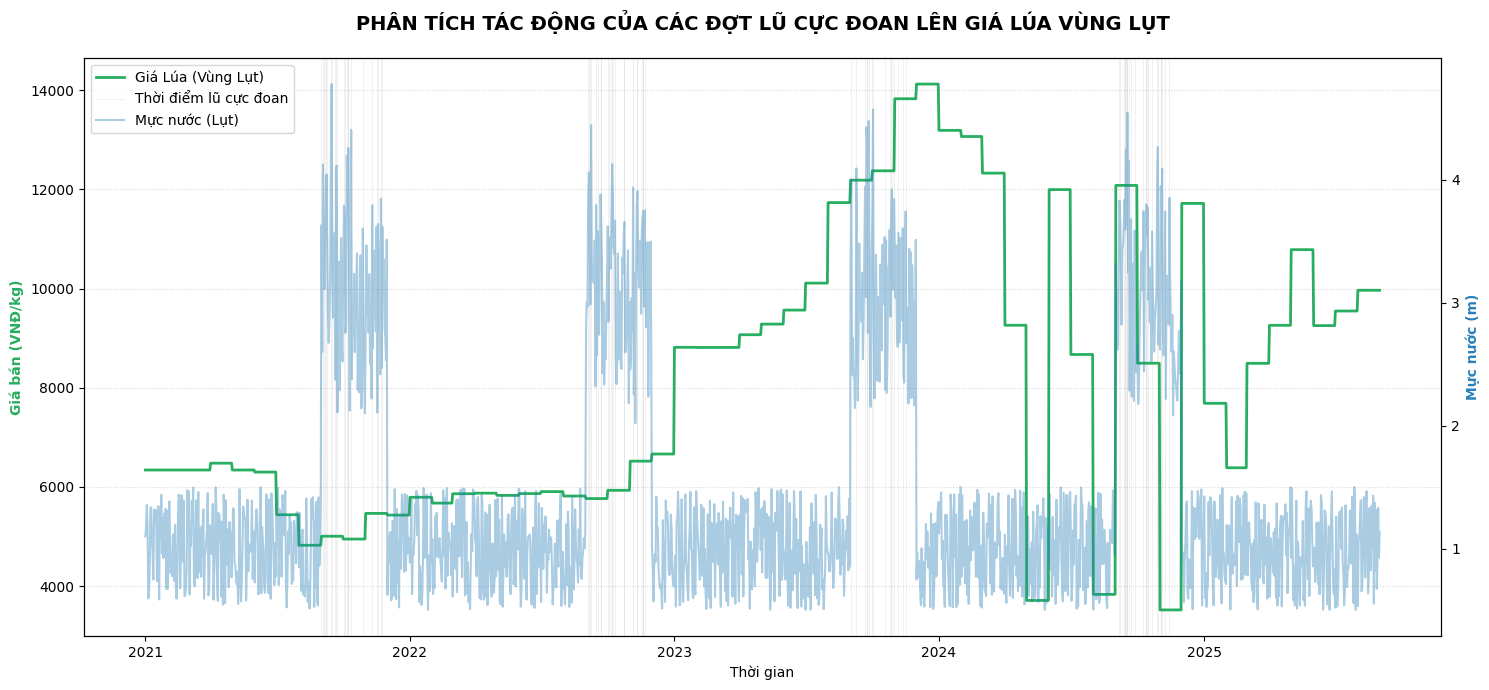

In [19]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('default')

plt.figure(figsize=(15, 7), facecolor='white')
ax1 = plt.gca()
ax1.set_facecolor('white')
ax2 = ax1.twinx()

ax1.plot(df_f['Date'], df_f['Rice_Common_Lut'], color='#27ae60',
         label='Giá Lúa (Vùng Lụt)', linewidth=2, zorder=3)

ax2.plot(df_f['Date'], df_f['WaterLevel_Lut'], color='#2980b9',
         alpha=0.4, label='Mực nước (Lụt)', zorder=2)

threshold_lut = df_f['WaterLevel_Lut'].quantile(0.95)
extreme_floods = df_f[df_f['WaterLevel_Lut'] >= threshold_lut]

for i, x in enumerate(extreme_floods['Date']):
    label = 'Thời điểm lũ cực đoan' if i == 0 else ""
    ax1.axvline(x=x, color='gray', linestyle='-', linewidth=0.5, alpha=0.15, zorder=1, label=label)


ax1.set_xlabel('Thời gian')
ax1.set_ylabel('Giá bán (VNĐ/kg)', color='#27ae60', fontweight='bold')
ax2.set_ylabel('Mực nước (m)', color='#2980b9', fontweight='bold')

plt.title('PHÂN TÍCH TÁC ĐỘNG CỦA CÁC ĐỢT LŨ CỰC ĐOAN LÊN GIÁ LÚA VÙNG LỤT',
          fontsize=14, fontweight='bold', pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white')

ax1.grid(True, axis='y', linestyle=':', alpha=0.5)
ax1.grid(False, axis='x')

plt.tight_layout()
plt.show()

# IV.Correlation Analysis

Heatmap

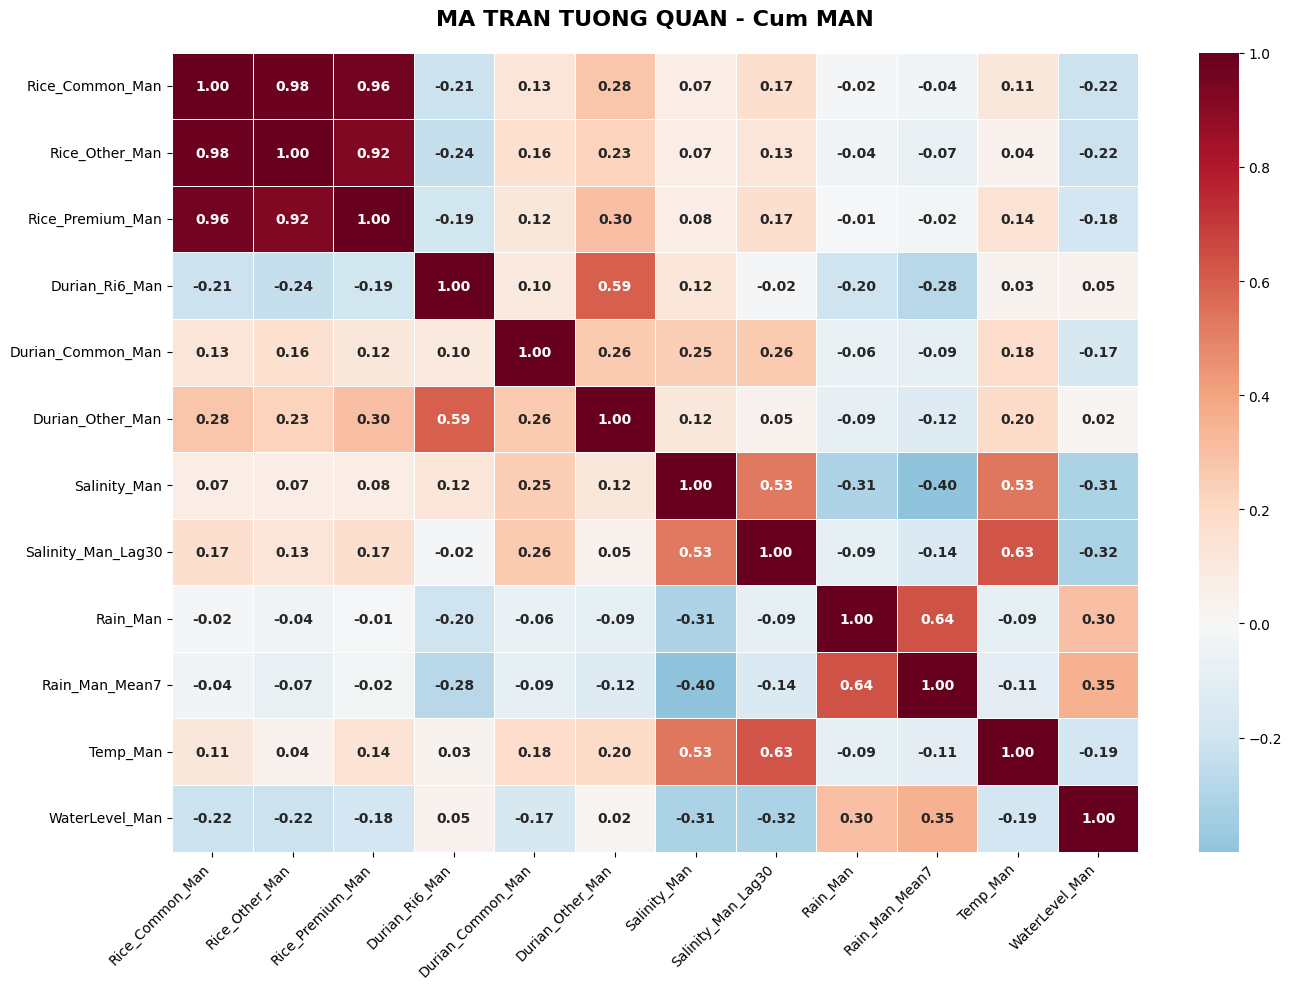

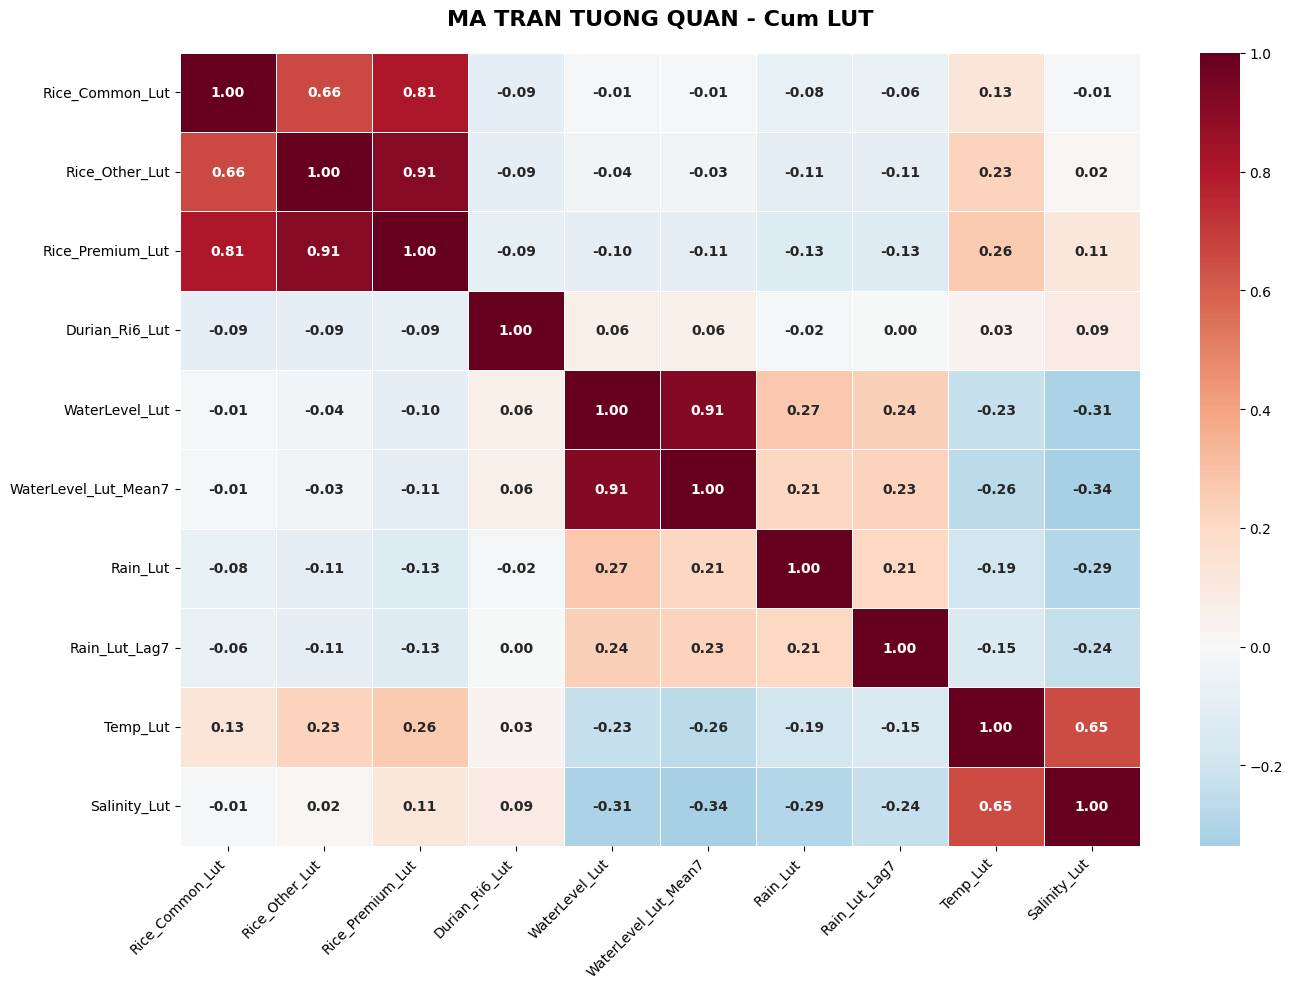

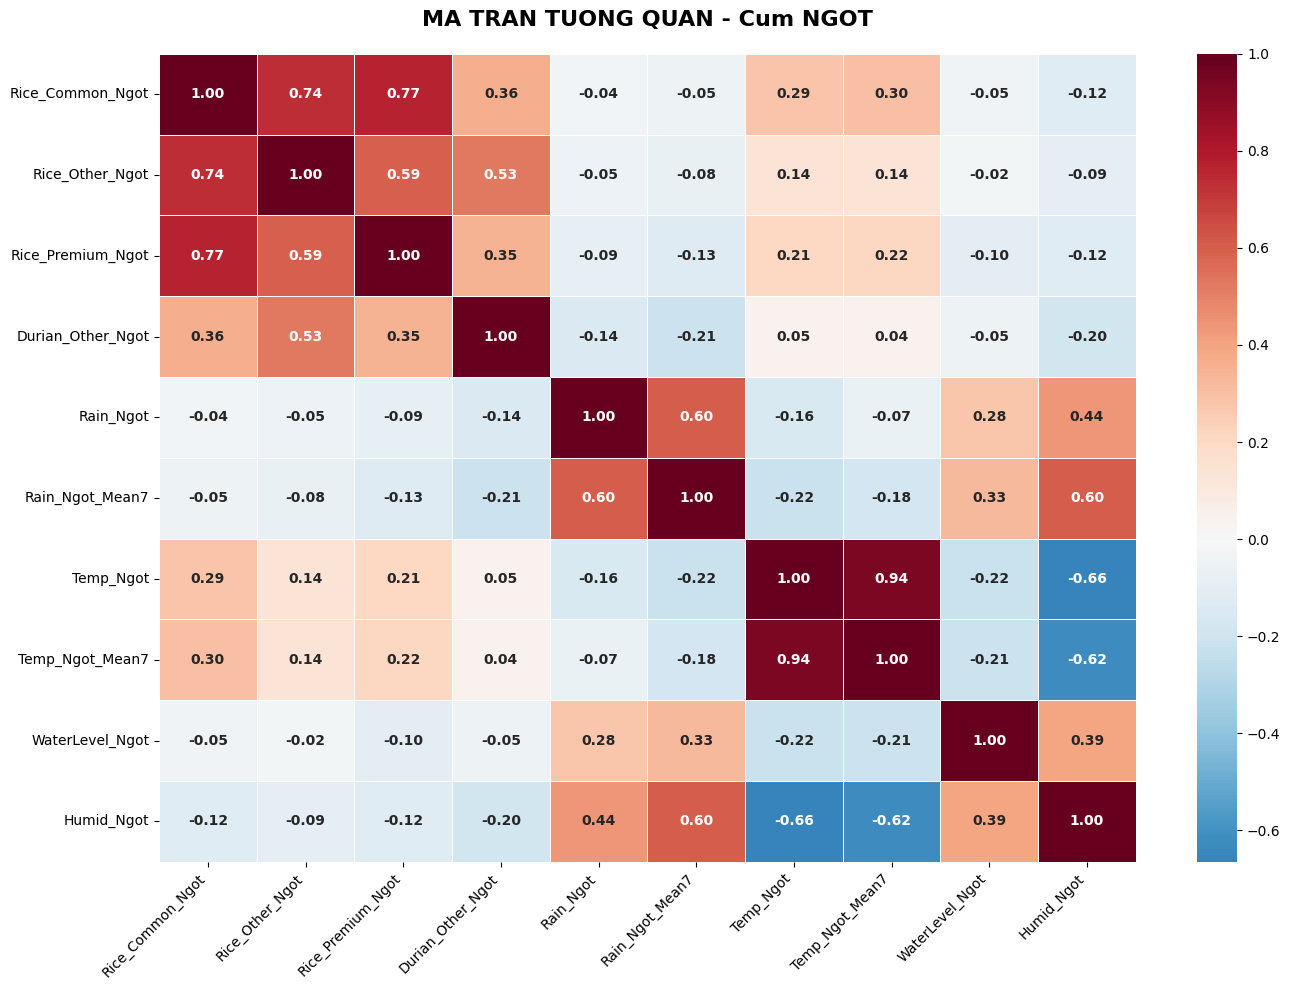

In [20]:
warnings.filterwarnings('ignore')

df_f = pd.read_csv('Mekong_Final_Features_v2.csv')

refined_clusters = {
    'Man': [
        'Rice_Common_Man', 'Rice_Other_Man', 'Rice_Premium_Man',
        'Durian_Ri6_Man', 'Durian_Common_Man', 'Durian_Other_Man',
        'Salinity_Man', 'Salinity_Man_Lag30', 'Rain_Man', 'Rain_Man_Mean7',
        'Temp_Man', 'WaterLevel_Man'
    ],
    'Lut': [
        'Rice_Common_Lut', 'Rice_Other_Lut', 'Rice_Premium_Lut',
        'Durian_Ri6_Lut',
        'WaterLevel_Lut', 'WaterLevel_Lut_Mean7', 'Rain_Lut', 'Rain_Lut_Lag7',
        'Temp_Lut', 'Salinity_Lut'
    ],
    'Ngot': [
        'Rice_Common_Ngot', 'Rice_Other_Ngot', 'Rice_Premium_Ngot',
        'Durian_Other_Ngot',
        'Rain_Ngot', 'Rain_Ngot_Mean7', 'Temp_Ngot', 'Temp_Ngot_Mean7',
        'WaterLevel_Ngot', 'Humid_Ngot'
    ]
}

for name, cols in refined_clusters.items():
    valid_cols = [c for c in cols if c in df_f.columns]
    corr = df_f[valid_cols].corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr,
                annot=True,
                cmap='RdBu_r',
                center=0,
                fmt=".2f",
                linewidths=0.5,
                annot_kws={"size": 10, "weight": "bold"})

    title_name = f'MA TRAN TUONG QUAN - Cum {name.upper()}'
    plt.title(title_name, fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

**Biểu đồ Tương quan (Scatter Plot + Regression)**

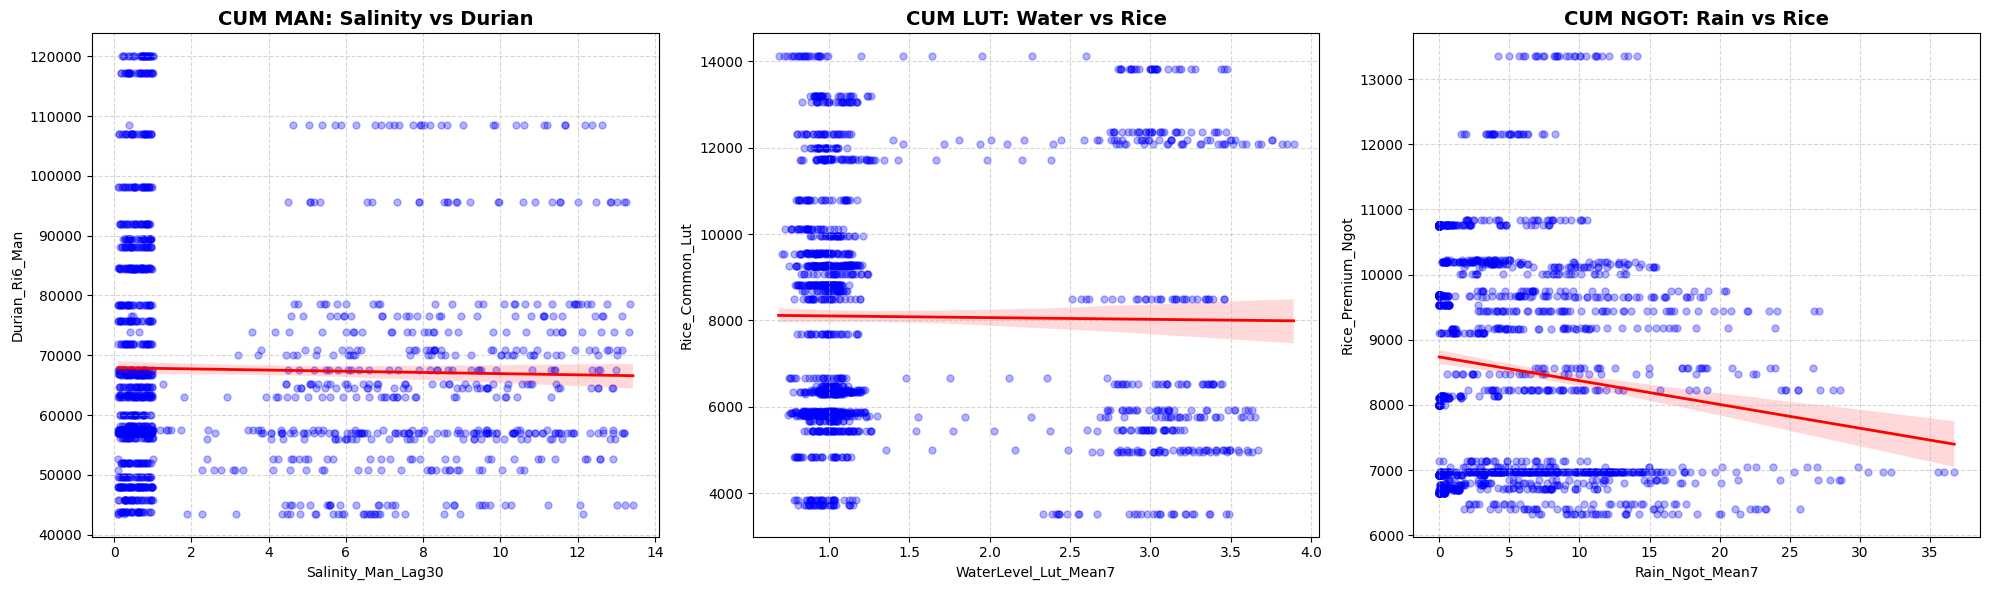

In [21]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
warnings.filterwarnings('ignore')

df_f = pd.read_csv('Mekong_Final_Features_v2.csv')

target_pairs = [
    ('Salinity_Man_Lag30', 'Durian_Ri6_Man', 'CUM MAN: Salinity vs Durian'),
    ('WaterLevel_Lut_Mean7', 'Rice_Common_Lut', 'CUM LUT: Water vs Rice'),
    ('Rain_Ngot_Mean7', 'Rice_Premium_Ngot', 'CUM NGOT: Rain vs Rice')
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (x_col, y_col, title) in enumerate(target_pairs):
    if x_col in df_f.columns and y_col in df_f.columns:
        plot_data = df_f[[x_col, y_col]].dropna()

        sns.regplot(
            data=plot_data,
            x=x_col,
            y=y_col,
            ax=axes[i],
            scatter_kws={'alpha':0.3, 's':25, 'color':'blue'},
            line_kws={'color':'red', 'lw':2}
        )
        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[i].set_title("Missing Columns")

plt.tight_layout()
plt.show()


# V.Modeling

Chia test - set

In [22]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

df = pd.read_csv('Mekong_Final_Features_v2.csv')

clusters_config = {
    'Man': {'target': 'Durian_Ri6_Man', 'features': ['Salinity_Man_Lag30', 'Rain_Man_Mean7', 'Temp_Man', 'WaterLevel_Man']},
    'Lut': {'target': 'Rice_Common_Lut', 'features': ['WaterLevel_Lut_Mean7', 'Rain_Lut_Lag7', 'Temp_Lut', 'Salinity_Lut']},
    'Ngot': {'target': 'Rice_Premium_Ngot', 'features': ['Rain_Ngot_Mean7', 'Temp_Ngot_Mean7', 'WaterLevel_Ngot', 'Humid_Ngot']}
}

results = {}

for name, config in clusters_config.items():
    target = config['target']

    df[f'{target}_Lag90'] = df[target].shift(90)
    current_features = config['features'] + [f'{target}_Lag90']

    data_cluster = df[current_features + [target]].dropna()
    X = data_cluster[current_features]
    y = data_cluster[target]

    #Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

    #RF
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        min_samples_leaf=30,
        n_jobs=-1,
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    rf_r2 = r2_score(y_test, y_pred_rf)

    # XG
    xgb_model = XGBRegressor(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.5,
        colsample_bytree=0.5,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xg = xgb_model.predict(X_test)
    xg_r2 = xg_r2 = r2_score(y_test, y_pred_xg)

    #save
    results[name] = {
        'y_test': y_test,
        'y_pred_rf': y_pred_rf,
        'y_pred_xg': y_pred_xg,
        'rf_r2': rf_r2,
        'xg_r2': xg_r2
    }

**RF: Biểu đồ dự báo và Phân phối sai số**

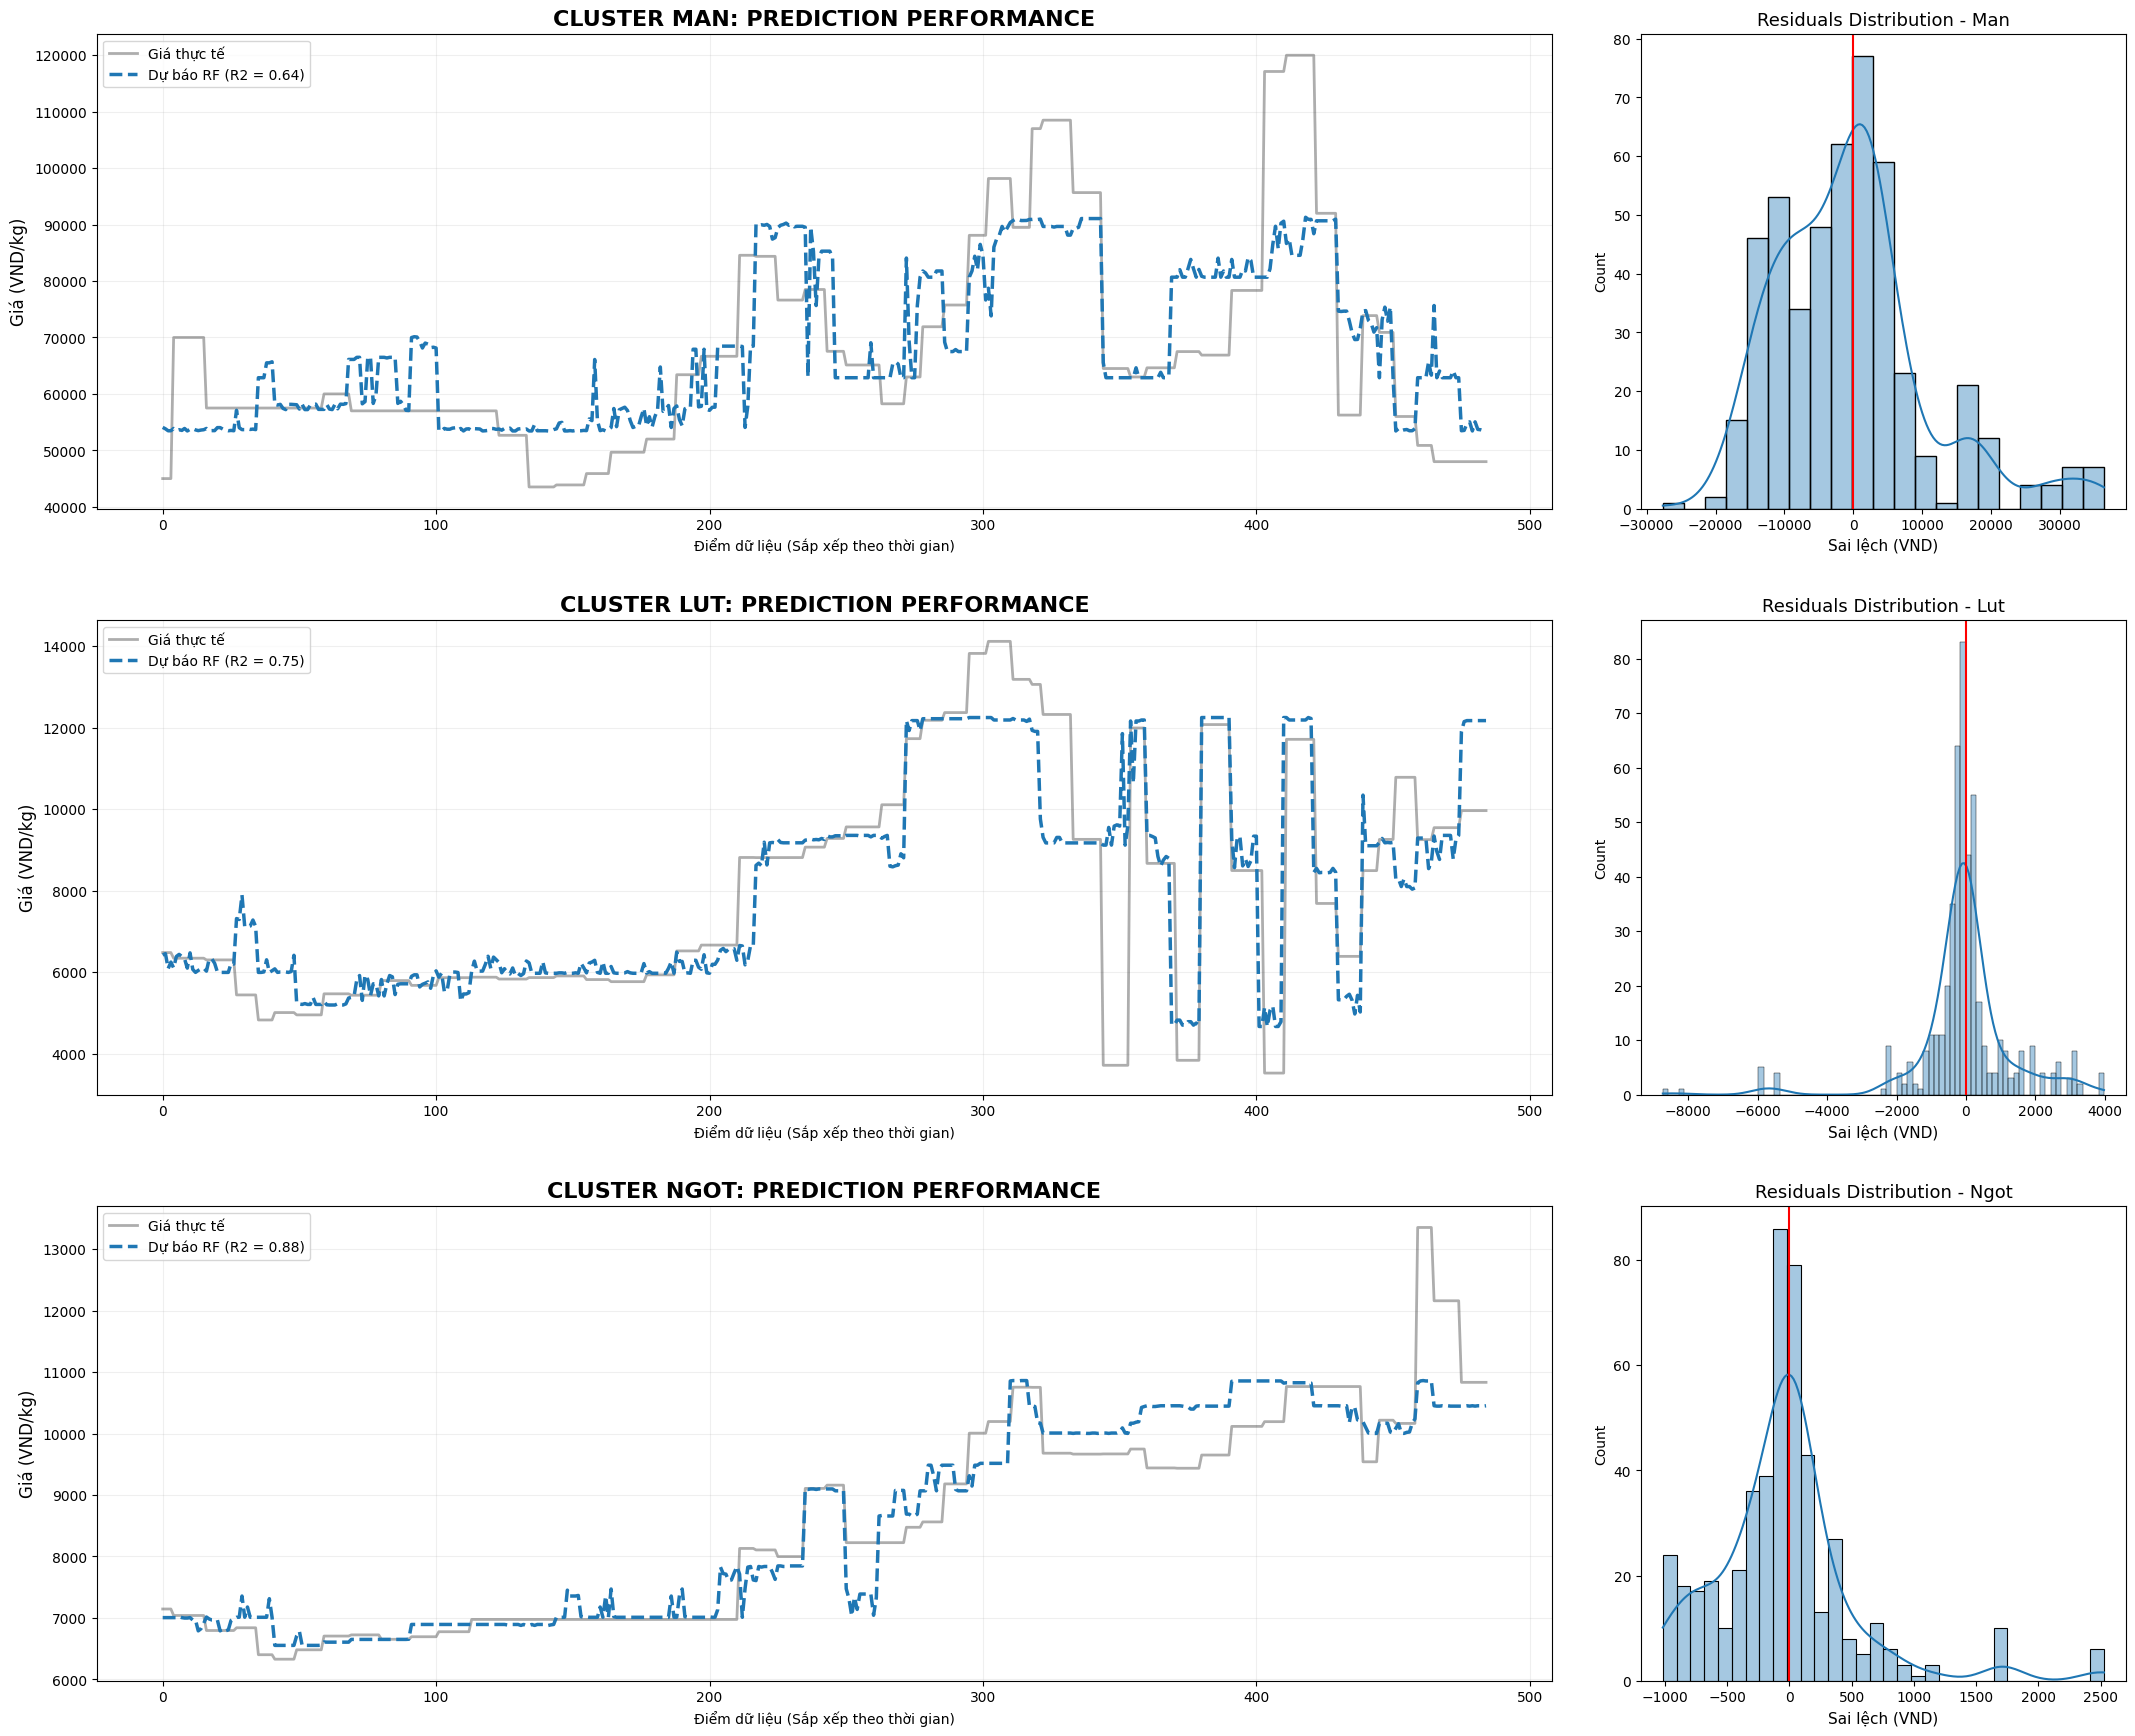

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(22, 18), gridspec_kw={'width_ratios': [3, 1]})

for i, name in enumerate(results.keys()):
    y_true = results[name]['y_test']
    y_pred = pd.Series(results[name]['y_pred_rf'], index=y_true.index)

    y_true_sorted = y_true.sort_index()
    y_pred_sorted = y_pred.sort_index()

    r2 = results[name]['rf_r2']
    errors = y_true - y_pred

    axes[i, 0].plot(y_true_sorted.values, label='Giá thực tế', color='#333333', alpha=0.4, linewidth=2)

    axes[i, 0].plot(y_pred_sorted.values, label=f'Dự báo RF (R2 = {r2:.2f})', color='#1f77b4', linestyle='--', linewidth=2.5)

    axes[i, 0].set_title(f'CLUSTER {name.upper()}: PREDICTION PERFORMANCE', fontweight='bold', fontsize=16)
    axes[i, 0].set_ylabel('Giá (VND/kg)', fontsize=12)
    axes[i, 0].set_xlabel('Điểm dữ liệu (Sắp xếp theo thời gian)', fontsize=10)
    axes[i, 0].legend(loc='upper left')
    axes[i, 0].grid(True, alpha=0.2)

    sns.histplot(errors, kde=True, ax=axes[i, 1], color='#1f77b4', alpha=0.4)
    axes[i, 1].axvline(x=0, color='red', linestyle='-', linewidth=1.5, label='Zero Error')

    axes[i, 1].set_title(f'Residuals Distribution - {name}', fontsize=13)
    axes[i, 1].set_xlabel('Sai lệch (VND)', fontsize=11)


plt.tight_layout(pad=3.0)


file_name = "hieu_nang_rf.png"
plt.savefig(file_name, dpi=300, bbox_inches='tight')

plt.show()


**XGBoost & Random Forest**


VÙNG       | RF R2 Score     | XG R2 Score    
---------------------------------------------
Man        | 0.64            | 0.50           
Lut        | 0.75            | 0.59           
Ngot       | 0.88            | 0.74           


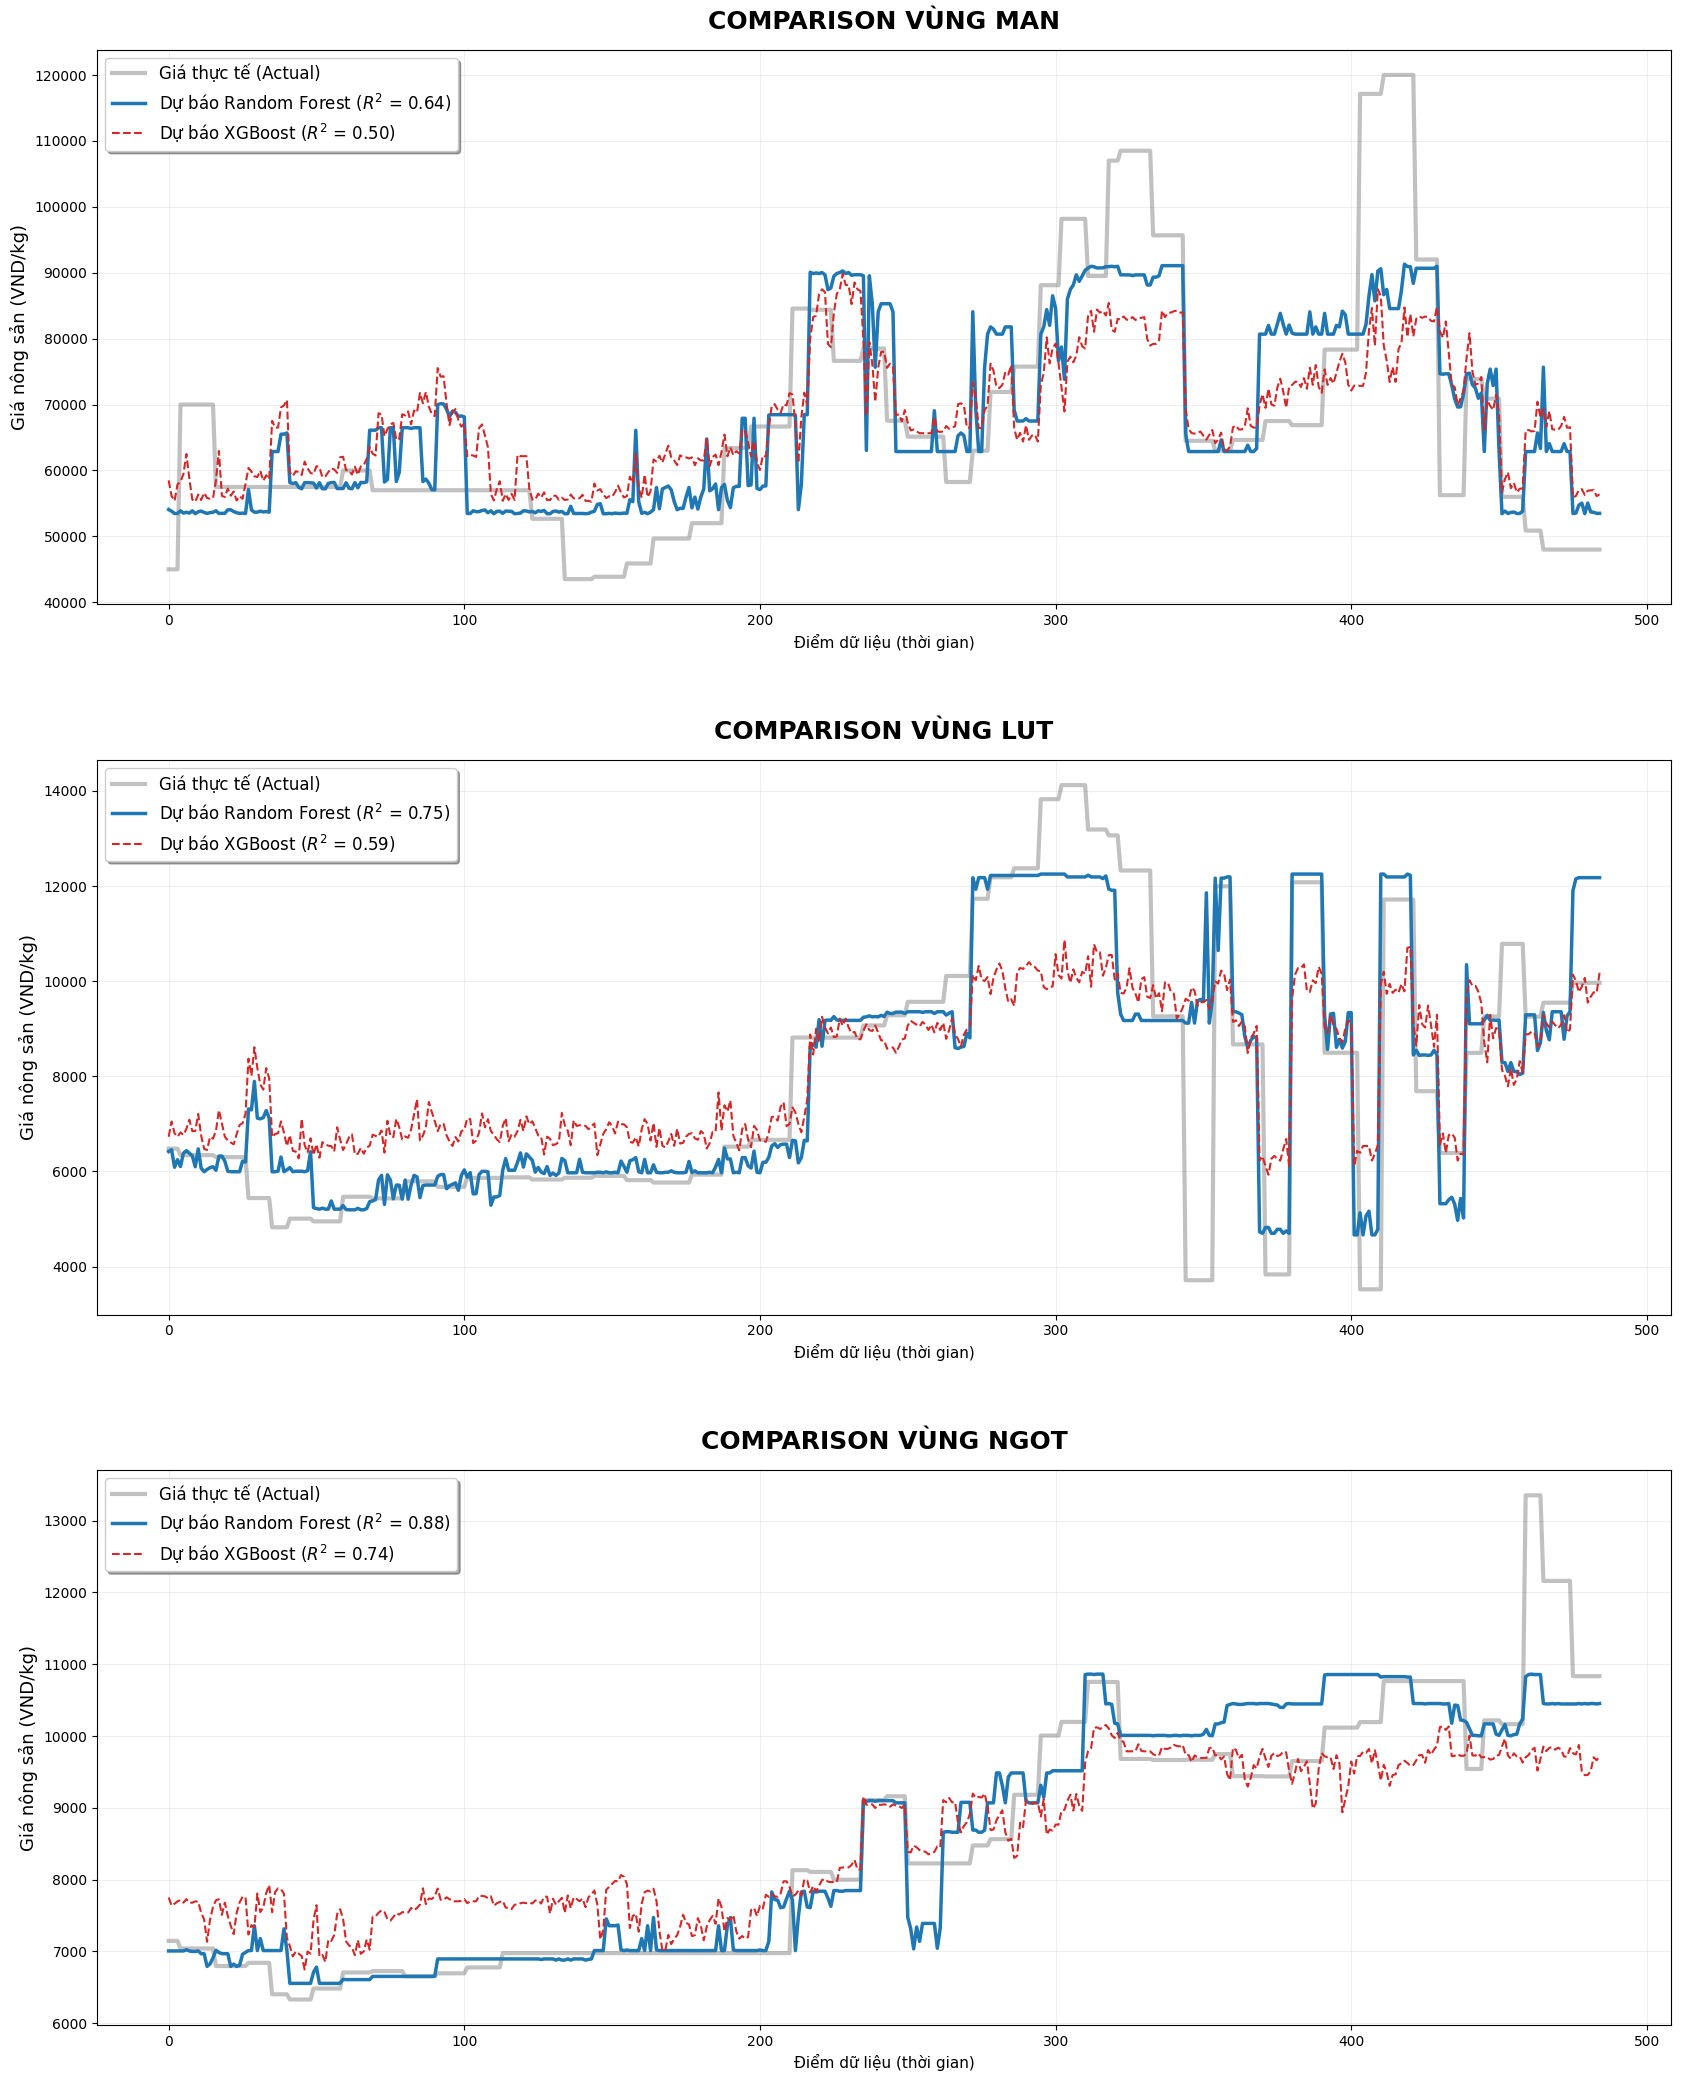

In [24]:

fig, axes = plt.subplots(3, 1, figsize=(18, 22))

for i, name in enumerate(results.keys()):
    y_true = results[name]['y_test'].sort_index()
    y_rf = pd.Series(results[name]['y_pred_rf'], index=results[name]['y_test'].index).sort_index()
    y_xg = pd.Series(results[name]['y_pred_xg'], index=results[name]['y_test'].index).sort_index()

    rf_r2 = results[name]['rf_r2']
    xg_r2 = results[name]['xg_r2']

    axes[i].plot(y_true.values, label='Giá thực tế (Actual)', color='#333333', linewidth=3, alpha=0.3)
    axes[i].plot(y_rf.values, label=f'Dự báo Random Forest ($R^2$ = {rf_r2:.2f})', color='#1f77b4', linestyle='-', linewidth=2.5)
    axes[i].plot(y_xg.values, label=f'Dự báo XGBoost ($R^2$ = {xg_r2:.2f})', color='#d62728', linestyle='--', linewidth=1.5)

    axes[i].set_title(f'COMPARISON VÙNG {name.upper()}', fontweight='bold', fontsize=18, pad=15)
    axes[i].set_ylabel('Giá nông sản (VND/kg)', fontsize=13)
    axes[i].set_xlabel('Điểm dữ liệu (thời gian)', fontsize=11)

    axes[i].legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
    axes[i].grid(True, alpha=0.2)

plt.tight_layout(pad=5.0)

print("\n" + "="*45)
print(f"{'VÙNG':<10} | {'RF R2 Score':<15} | {'XG R2 Score':<15}")
print("-" * 45)
for name, data in results.items():
    print(f"{name:<10} | {data['rf_r2']:<15.2f} | {data['xg_r2']:<15.2f}")
print("="*45)

SO SÁNH CHI TIẾT HIỆU NĂNG MÔ HÌNH

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

evaluation_results = []

for name, data in results.items():
    y_test = data['y_test']
    y_pred_rf = data['y_pred_rf']
    y_pred_xg = data['y_pred_xg']

    # RF-
    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    rf_r2 = r2_score(y_test, y_pred_rf)

    #XG
    xg_mae = mean_absolute_error(y_test, y_pred_xg)
    xg_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xg))
    xg_r2 = r2_score(y_test, y_pred_xg)

    evaluation_results.append({
        'Vùng': name,
        'Mô hình': 'Random Forest',
        'MAE (VND)': round(rf_mae, 2),
        'RMSE (VND)': round(rf_rmse, 2),
        'R2 Score': round(rf_r2, 2)
    })
    evaluation_results.append({
        'Vùng': name,
        'Mô hình': 'XGBoost',
        'MAE (VND)': round(xg_mae, 2),
        'RMSE (VND)': round(xg_rmse, 2),
        'R2 Score': round(xg_r2, 2)
    })

df_eval = pd.DataFrame(evaluation_results)

print("--- BẢNG SO SÁNH CHI TIẾT HIỆU NĂNG MÔ HÌNH ---")
display(df_eval.sort_values(by=['Vùng', 'R2 Score'], ascending=[True, False]))


--- BẢNG SO SÁNH CHI TIẾT HIỆU NĂNG MÔ HÌNH ---


,Vùng,Mô hình,MAE (VND),RMSE (VND),R2 Score
2,Lut,Random Forest,781.11,1398.96,0.75
3,Lut,XGBoost,1355.72,1785.42,0.59
0,Man,Random Forest,8201.41,11056.89,0.64
1,Man,XGBoost,9360.82,12932.18,0.50
4,Ngot,Random Forest,376.55,569.62,0.88
5,Ngot,XGBoost,652.09,855.92,0.74


# VI.Evaluation & Interpretation

**Biểu đồ Feature Importance (Tầm quan trọng của biến)**

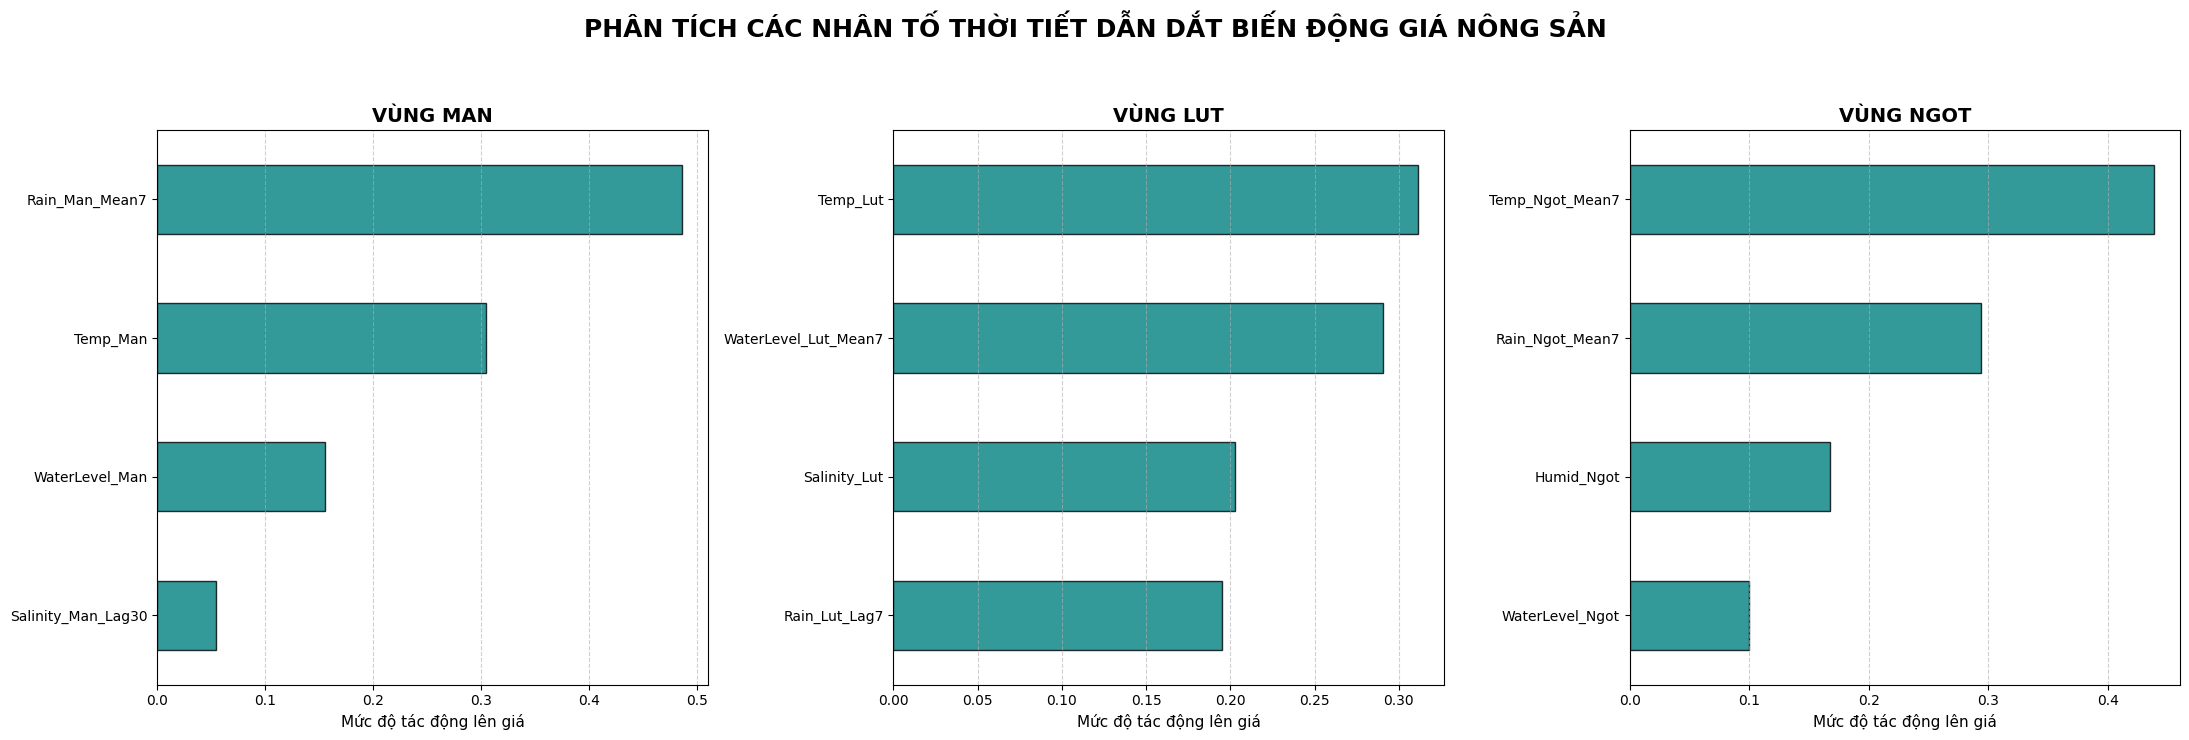

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, name in enumerate(clusters_config.keys()):
    target = clusters_config[name]['target']
    weather_features = clusters_config[name]['features']

    data_cluster = df[weather_features + [target]].dropna()
    X = data_cluster[weather_features]
    y = data_cluster[target]

    rf_weather = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_weather.fit(X, y)

    importances = rf_weather.feature_importances_
    feat_importances = pd.Series(importances, index=weather_features).sort_values(ascending=True)

    feat_importances.plot(kind='barh', ax=axes[i], color='teal', edgecolor='black', alpha=0.8)

    axes[i].set_title(f'VÙNG {name.upper()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Mức độ tác động lên giá', fontsize=11)
    axes[i].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('PHÂN TÍCH CÁC NHÂN TỐ THỜI TIẾT DẪN DẮT BIẾN ĐỘNG GIÁ NÔNG SẢN',
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
